# Q-Learning 与 SARSA
在人工智能的领域中，强化学习是一种让智能体通过与环境交互来学习如何达成目标的方法。

想象一下教一只小狗学习新指令：它做出一个动作（如坐下），你给予奖励（一块零食），它就会逐渐学会在听到指令时做出正确的反应。Q-learning 和 SARSA 就是强化学习中两种经典且至关重要的算法，它们是智能体学习什么动作在什么状态下最好的核心工具。本文将为你清晰地解析这两种算法的原理、区别与实现。

-----

## 强化学习与马尔可夫决策过程（MDP）
在深入 Q-learning 和 SARSA 之前，我们需要先了解强化学习的基本框架——马尔可夫决策过程（MDP）。



### 核心概念
强化学习的问题通常被建模为一个马尔可夫决策过程（MDP），它由以下几个元素组成：
- **智能体** : 这是学习和决策的主体。
- **环境** : 智能体与之交互的外部世界。
- **状态（State）** : 描述环境当前情况的变量。
- **动作（Action）** : 智能体在某个状态下可以采取的行为。
- **奖励（Reward）** : 智能体采取某个动作后从环境中获得的反馈的即时收益。
- **策略（Policy）** : 智能体根据当前状态选择动作的规则或函数 , 是学习的结果。

### 目标与价值函数
智能体的终极目标是最大化长期累积奖励，而不仅仅是即时奖励。为此，我们引入了价值函数。
- **状态价值函数 V(s)**： 表示从状态 s 开始，遵循特定策略能获得的期望累积奖励。
- **动作价值函数 Q(s, a)**： 表示在状态 s 下执行动作 a，然后遵循特定策略能获得的期望累积奖励。Q-learning 和 SARSA 的核心就是学习这个 Q 函数。

为了平衡即时奖励和未来奖励，我们使用折扣因子 γ (取值范围通常为 [0, 1])。未来第 k 步的奖励会被乘以 γ^k，这意味着智能体更看重近期奖励。

-----

## Q-Learning : 离策略的时序差分学习
Q-learning 是一种离策略的强化学习算法，它通过学习动作价值函数 Q(s, a) 来指导智能体的决策。Q-learning 的核心思想是利用贝尔曼方程来更新 Q 值，使其逐渐逼近最优动作价值函数 Q*。

### 算法核心 : Q 值更新公式
$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \max_{a} Q(s_{t+1}, a) - Q(s_t, a_t) \right]
$$

其中：
- $Q(s_t, a_t)$ : 在时间 t , 状态 s_t 下执行动作 a_t 的当前 Q 值。
- $\alpha$ : 学习率，控制新信息覆盖旧信息的程度。(通常取值范围为 [0, 1])
- $r_{t+1}$ : 在时间 t+1 时刻获得的即时奖励。
- $\gamma$ : 折扣因子，权衡即时奖励和未来奖励的重要性。
- $\max_{a} Q(s_{t+1}, a)$ : 在下一状态 s_{t+1} 下所有可能动作的最大 Q 值，代表智能体在下一状态下的最佳预期奖励。
- [ r_{t+1} + γ * max_{a} Q(s_{t+1}, a) - Q(s_t, a_t) ]： 称为时序差分误差。它是"目标值"（即时奖励加未来最佳估计）与"当前估计值"的差值。算法通过减小这个误差来更新 Q 值。

### 离策略的含义
Q-learning 被称为离策略，是因为它在更新 Q 值时，用于评估未来价值的动作（max_{a} Q(s_{t+1}, a)）与智能体实际执行探索的动作是分离的。

- 行为策略： 用于选择实际执行动作的策略（如 ε-greedy，以一定概率随机探索）。
- 目标策略： 用于更新 Q 值的策略，是一个完全贪婪的策略（总是选择当前 Q 值最大的动作）。

这种分离使得 Q-learning 能够大胆地利用其对最优路径的估计进行学习，即使当前正在采取随机探索。

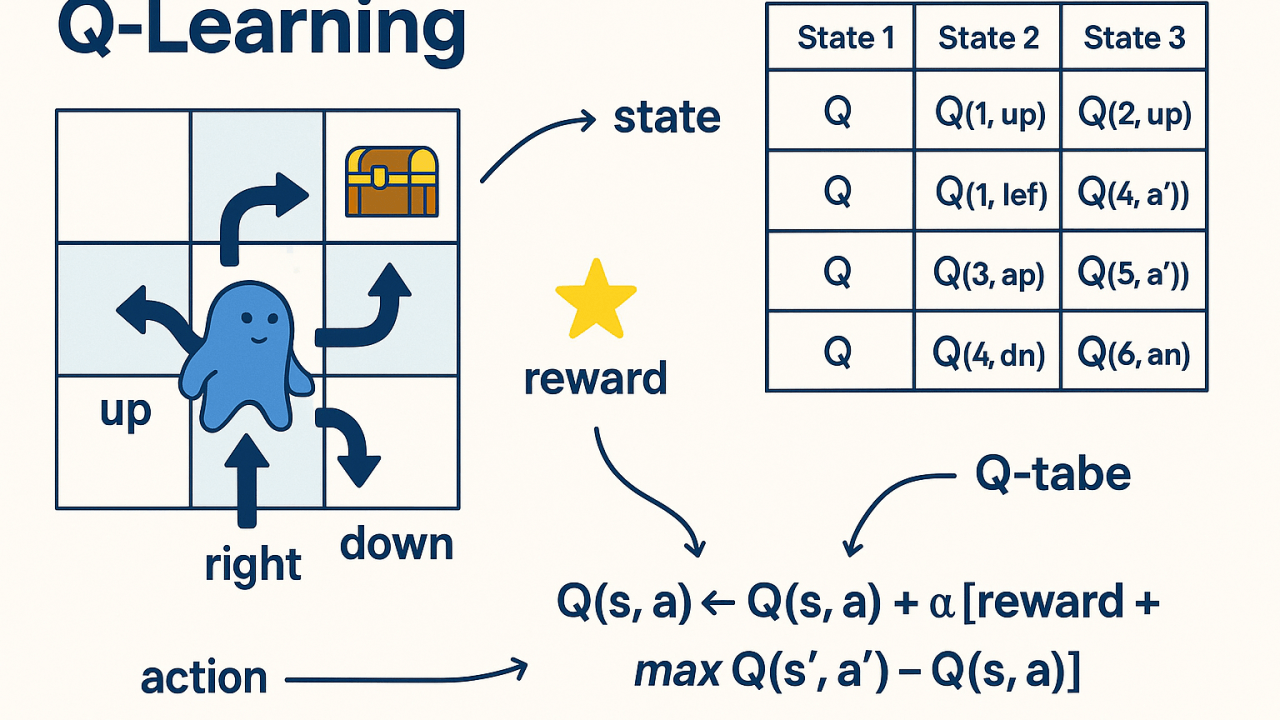

### 算法流程
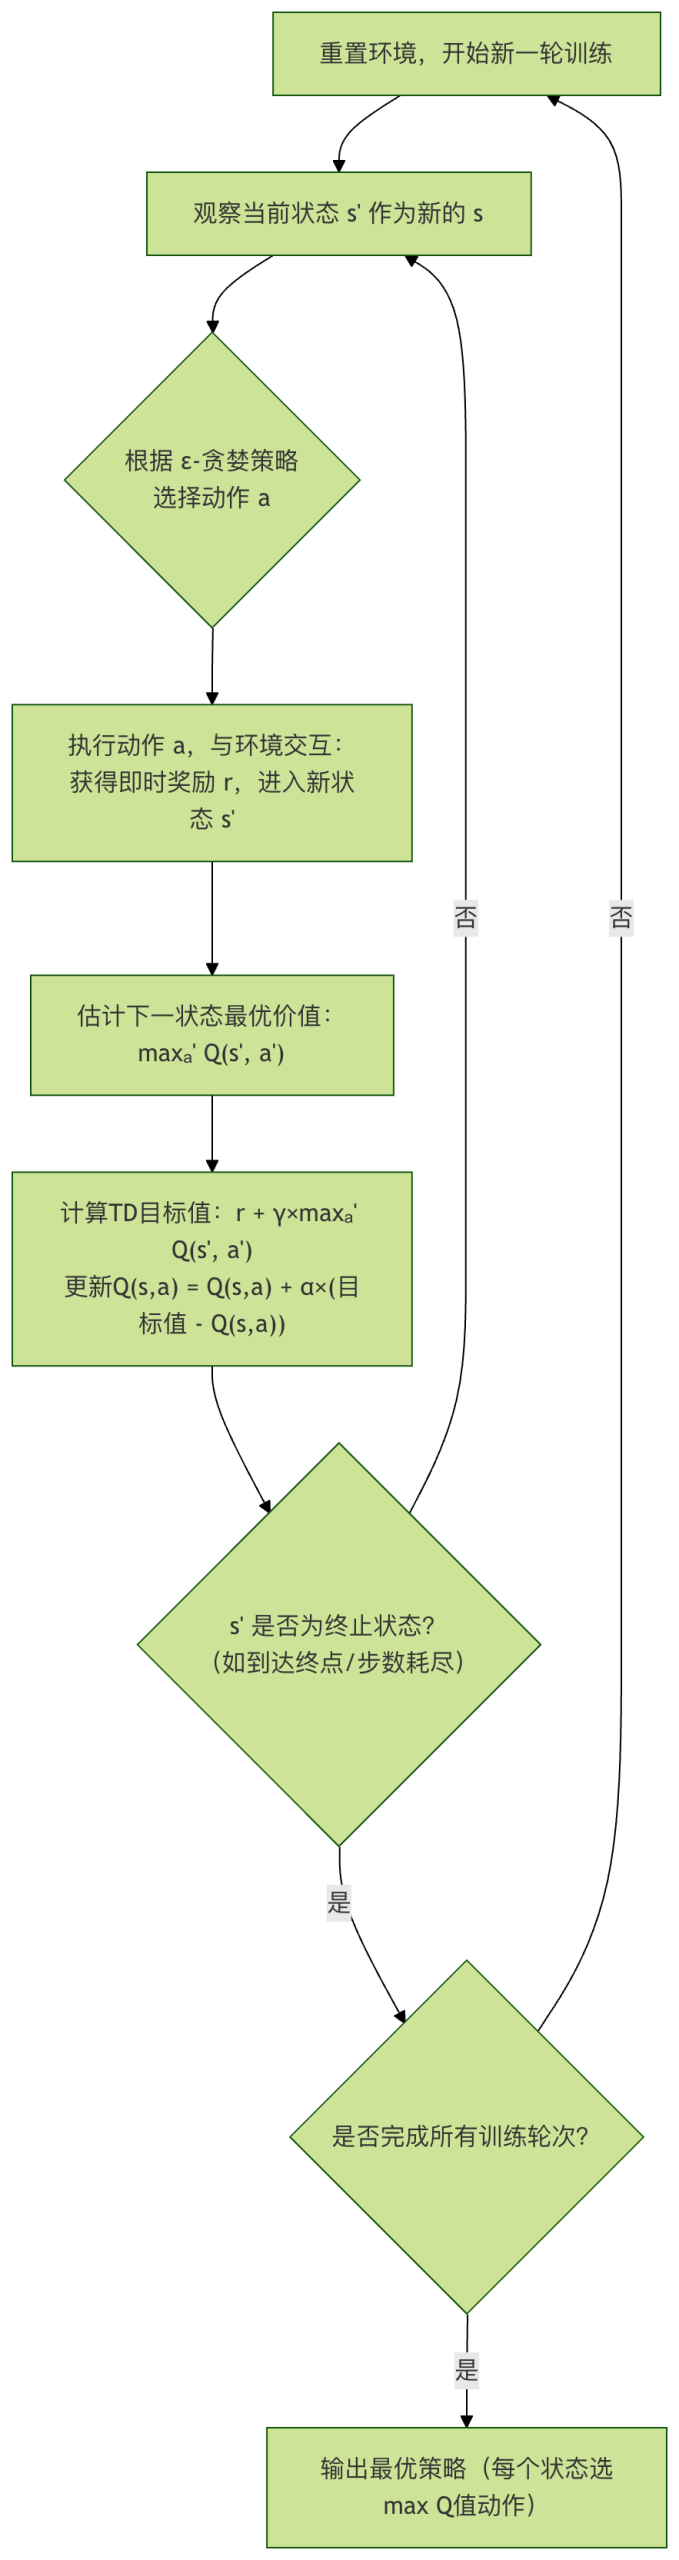

----

## SARSA : 同策略的时序差分学习
SARSA 的名称来源于其更新过程涉及的状态-动作序列：(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})。它是一种同策略算法。

### 算法核心 : Q 值更新公式
SARSA 的更新公式如下：
$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]
$$

其中：
- $Q(s_t, a_t)$ : 在时间 t , 状态 s_t 下执行动作 a_t 的当前 Q 值。
- $\alpha$ : 学习率，控制新信息覆盖旧信息的程度。
- $r_{t+1}$ : 在时间 t+1 时刻获得的即时奖励。
- $\gamma$ : 折扣因子，权衡即时奖励和未来奖励的重要性。
- $Q(s_{t+1}, a_{t+1})$ : 在下一状态 s_{t+1} 下执行动作 a_{t+1} 的 Q 值，代表智能体在下一状态下实际选择动作的预期奖励。
- [ r_{t+1} + γ * Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) ]： 时序差分误差。它是"目标值"（即时奖励加下一状态实际选择动作的预期奖励）与"当前估计值"的差值。算法通过减小这个误差来更新 Q 值。

请注意第二部分使用
- Q-learing使用 :  γ * max_{a} Q(s_{t+1}, a)
- SARSA使用 :  γ * Q(s_{t+1}, a_{t+1})

### 同策略的含义
SARSA 被称为同策略，是因为它在更新 Q 值时，使用的动作 a_{t+1} 是智能体在下一状态 s_{t+1} 实际选择的动作。这意味着 SARSA 的学习过程与智能体的行为策略紧密相关。如果智能体采用 ε-greedy 策略进行探索，那么 SARSA 的更新将反映出这种探索行为的影响。
- 它评估和优化的是智能体当前正在执行的策略，而不是一个理想化的最优策略。
- 因此，SARSA 在某些环境中可能会表现得更为保守，因为它考虑了智能体实际采取的动作，而不是假设智能体总是选择最优动作。


-----

## Q-Learning 与 SARSA 的比较
| 特性 | Q-Learning | SARSA |
| --- | --- | --- |
| 策略类型 | 离策略 | 同策略 |
| 更新目标 | 未来状态的最大 Q 值 , 基于最优动作: γ * max_{a} Q(s_{t+1}, a) | 下一状态实际选择动作的 Q 值 , 基于当前策略: γ * Q(s_{t+1}, a_{t+1}) |
| 学习行为 | 更激进，倾向于利用当前最佳估计 | 更保守，考虑实际行为 |
| 收敛性 | 在适当条件下收敛到最优策略 | 在适当条件下收敛到最优策略 |
| 适用环境 | 适用于需要快速学习最优策略的环境 | 适用于需要考虑实际行为影响的环境 |

-----


In [4]:
#  环境设置
import numpy as np
import random

class GridWorld:
    def __init__(self , size = 4):
        self.size = size
        self.state = (0, 0)  # 初始状态
        self.goal = (size - 1, size - 1)  # 目标状态
        self.actions = ['up', 'down', 'left', 'right']  # 可选动作
        self.action_map = {
            'up': (-1, 0),
            'down': (1, 0),
            'left': (0, -1),
            'right': (0, 1)
        }

    def reset(self):
        """重置环境到初始状态"""
        self.state = (0, 0)
        return self.state

    def step(self , action):
        """执行动作并返回新状态、奖励和是否结束"""
        # 获取动作对应的移动
        move = self.action_map[action]
        new_state = (self.state[0] + move[0], self.state[1] + move[1])

        # 确保新状态在网格范围内
        new_state = (max(0, min(self.size - 1, new_state[0])), 
                     max(0, min(self.size - 1, new_state[1])))

        self.state = new_state

        # 计算奖励 , 如果达到目标奖励为10，否则每步惩罚-1
        if self.state == self.goal:
            reward = 10  # 达到目标奖励
            done = True
        else:
            reward = -1  # 每步惩罚
            done = False

        return self.state, reward, done
    
    def get_actions(self):
        """返回可用动作列表"""
        return self.actions

In [5]:
def q_learning(env, episodes=500, alpha=0.1, gamma=0.9, epsilon=0.1):
    """
    实现 Q-learning 算法
    env: 环境对象
    episodes: 训练轮数
    alpha: 学习率
    gamma: 折扣因子
    epsilon: ε-greedy 策略中的探索概率
    """
    # 初始化 Q 表，维度为 [网格行, 网格列, 动作数]
    q_table = np.zeros((env.size, env.size, len(env.actions)))

    for episode in range(episodes):
        state = env.reset()
        done = False

        while not done:
            # 1. ε-greedy 策略选择动作
            if random.uniform(0, 1) < epsilon:
                action_idx = random.randint(0, len(env.actions)-1) # 探索：随机选
            else:
                action_idx = np.argmax(q_table[state[0], state[1], :]) # 利用：选Q值最大的
            action = env.actions[action_idx]

            # 2. 执行动作，得到反馈
            next_state, reward, done = env.step(action)

            # 3. Q-learning 核心更新
            # 当前状态-动作对的 Q 值
            current_q = q_table[state[0], state[1], action_idx]
            # 下一个状态的最大 Q 值（离策略的关键）
            next_max_q = np.max(q_table[next_state[0], next_state[1], :])
            # 计算目标 Q 值
            target_q = reward + gamma * next_max_q
            # 更新 Q 表
            q_table[state[0], state[1], action_idx] = current_q + alpha * (target_q - current_q)

            # 转移到下一个状态
            state = next_state

    return q_table

In [6]:
def sarsa(env, episodes=500, alpha=0.1, gamma=0.9, epsilon=0.1):
    """
    实现 SARSA 算法
    参数含义同 Q-learning
    """
    q_table = np.zeros((env.size, env.size, len(env.actions)))

    for episode in range(episodes):
        state = env.reset()
        done = False

        # SARSA 需要先为初始状态选择一个动作
        if random.uniform(0, 1) < epsilon:
            action_idx = random.randint(0, len(env.actions)-1)
        else:
            action_idx = np.argmax(q_table[state[0], state[1], :])
        action = env.actions[action_idx]

        while not done:
            # 1. 执行上一步选好的动作
            next_state, reward, done = env.step(action)

            # 2. 为下一个状态选择动作（同策略，依然用 ε-greedy）
            if random.uniform(0, 1) < epsilon:
                next_action_idx = random.randint(0, len(env.actions)-1)
            else:
                next_action_idx = np.argmax(q_table[next_state[0], next_state[1], :])
            next_action = env.actions[next_action_idx]

            # 3. SARSA 核心更新
            current_q = q_table[state[0], state[1], action_idx]
            # 关键区别：使用下一个状态**实际要执行的动作**的 Q 值
            next_q = q_table[next_state[0], next_state[1], next_action_idx]
            target_q = reward + gamma * next_q
            q_table[state[0], state[1], action_idx] = current_q + alpha * (target_q - current_q)

            # 4. 为下一步迭代更新状态和动作
            state = next_state
            action_idx = next_action_idx
            action = next_action

    return q_table

In [7]:
def test_policy(env, q_table, episodes=10):
    """测试学到的策略"""
    total_rewards = []
    for _ in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0
        steps = []

        while not done:
            # 测试时使用贪婪策略（不探索）
            action_idx = np.argmax(q_table[state[0], state[1], :])
            action = env.actions[action_idx]
            next_state, reward, done = env.step(action)
            steps.append(action[0].upper()) # 记录动作首字母
            total_reward += reward
            state = next_state

        total_rewards.append(total_reward)
        print(f"Episode steps: {steps}, Total reward: {total_reward}")

    print(f"平均奖励: {np.mean(total_rewards):.2f}")

# 创建环境
env = GridWorld(size=4)

print("=== 训练并测试 Q-learning ===")
q_table_ql = q_learning(env, episodes=1000)
test_policy(env, q_table_ql)

print("\n=== 训练并测试 SARSA ===")
env.reset() # 重置环境状态
q_table_sarsa = sarsa(env, episodes=1000)
test_policy(env, q_table_sarsa)

# 简单比较最终策略
print("\n=== 策略对比（从起点(0,0)出发的动作）===")
start_q_values = q_table_ql[0, 0, :]
start_sarsa_values = q_table_sarsa[0, 0, :]
print(f"Q-learning Q值: {dict(zip(env.actions, start_q_values))}")
print(f"推荐动作: {env.actions[np.argmax(start_q_values)]}")
print(f"SARSA Q值: {dict(zip(env.actions, start_sarsa_values))}")
print(f"推荐动作: {env.actions[np.argmax(start_sarsa_values)]}")

=== 训练并测试 Q-learning ===
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'R', 'D'], Total reward: 5
平均奖励: 5.00

=== 训练并测试 SARSA ===
Episode steps: ['R', 'D', 'R', 'D', 'D', 'R'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'D', 'R'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'D', 'R'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'D', 'R'], Total reward: 5
Episode steps: ['R', 'D', 'R', 'D', 'D', 'R'], Total reward: 